In [2]:
import pandas as pd

train = pd.read_csv('../data/train.csv')
store = pd.read_csv('../data/store.csv')

train.head()

/var/folders/2h/5j7jrrz10pb4sj6zfztxf_680000gn/T/ipykernel_50179/151770172.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('../data/train.csv')


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [6]:
train.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [8]:
df = train.merge(store, on='Store', how='left')
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [10]:
df['Date'] = pd.to_datetime(df['Date'])


In [12]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

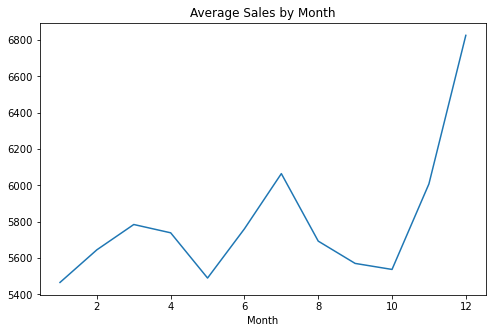

In [14]:
import matplotlib.pyplot as plt

df.groupby('Month')['Sales'].mean().plot(figsize=(8,5))
plt.title('Average Sales by Month')
plt.show()

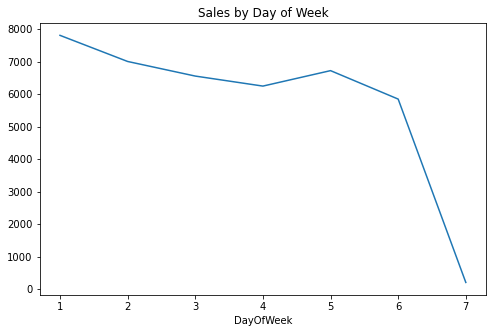

In [16]:
df.groupby('DayOfWeek')['Sales'].mean().plot(figsize=(8,5))
plt.title('Sales by Day of Week')
plt.show()

In [18]:
df.groupby('Promo')['Sales'].mean()

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64

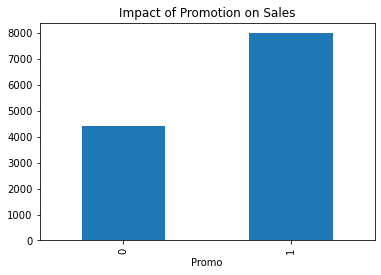

In [20]:
df.groupby('Promo')['Sales'].mean().plot(kind='bar')
plt.title('Impact of Promotion on Sales')
plt.show()

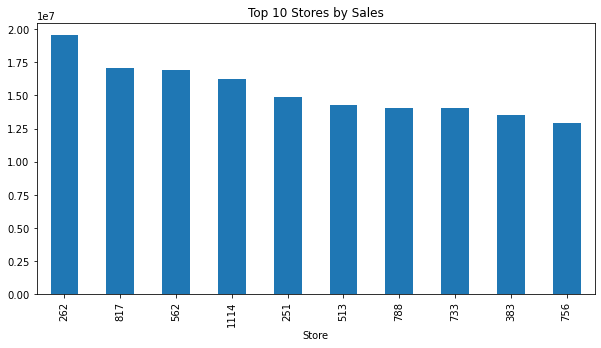

In [22]:
top_stores = df.groupby('Store')['Sales'].sum().sort_values(ascending=False).head(10)
top_stores.plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Stores by Sales')
plt.show()

Sales peak significantly in December, confirming strong seasonal demand driven by holiday periods, indicating the need for increased inventory and staffing during peak months
Sunday shows the highest average sales, suggesting customer footfall is concentrated on weekends, highlighting opportunities for targeted promotions and workforce optimisation
Promotional campaigns result in approximately a 100% increase in average sales, demonstrating a strong dependency on promotions and indicating their effectiveness as a primary revenue driver
Sales distribution across stores is highly uneven, with top-performing stores contributing a disproportionate share of total revenue, suggesting potential for store-level strategy optimisation and resource allocation

<AxesSubplot:xlabel='Date'>

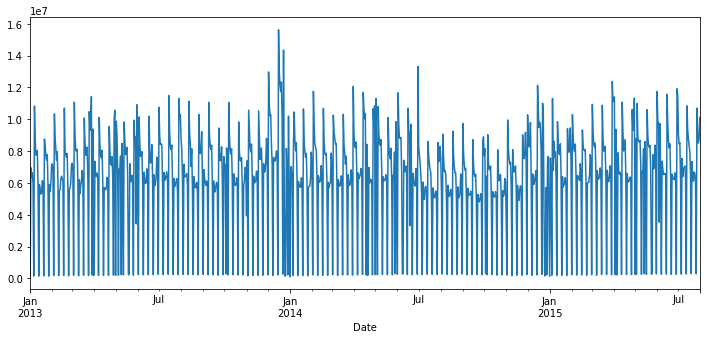

In [26]:
daily_sales = df.groupby('Date')['Sales'].sum()
daily_sales.plot(figsize=(12,5))

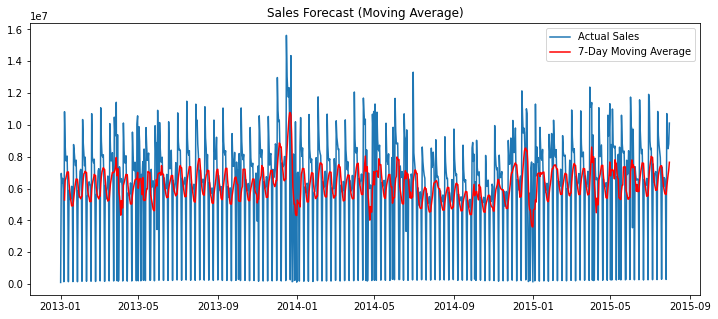

In [28]:
forecast = daily_sales.rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(daily_sales, label='Actual Sales')
plt.plot(forecast, label='7-Day Moving Average', color='red')
plt.legend()
plt.title('Sales Forecast (Moving Average)')
plt.show()

#Implemented a 7-day moving average model to smooth demand fluctuations and capture short-term trends

#Forecast highlights clear seasonality and demand variability, enabling better short-term inventory planning

In [32]:
avg_demand = daily_sales.mean()
std_demand = daily_sales.std()

print("Average Demand:", avg_demand)
print("Demand Std Dev:", std_demand)

Average Demand: 6234798.962845011
Demand Std Dev: 3130535.8719555507


Business assumption 

We assume:

Service Level = 95% → Z = 1.65
Lead Time = 7 days

In [36]:
import numpy as np

Z = 1.65
lead_time = 7

safety_stock = Z * std_demand * np.sqrt(lead_time)

print("Safety Stock:", round(safety_stock))

Safety Stock: 13666322


In [39]:
reorder_point = (avg_demand * lead_time) + safety_stock

print("Reorder Point:", round(reorder_point))

Reorder Point: 57309915


EOQ Assumptions 
Annual Demand (D) = avg_demand × 365

Ordering Cost (S) = 500 (assumed)

Holding Cost (H) = 2 per unit

In [44]:
D = avg_demand * 365
S = 500
H = 2

EOQ = np.sqrt((2 * D * S) / H)

print("EOQ:", round(EOQ))

EOQ: 1066701


Inventory Optimisation Insights

1.Calculated safety stock levels to maintain a 95% service level under demand uncertainty

2.Established reorder points based on demand variability and supplier lead time to minimise stockouts

3.Implemented EOQ model to balance ordering and holding costs, improving inventory efficiency

4.Designed a data-driven inventory framework enabling better supply chain decision-making